In [1]:
# 导入必要的库
import matplotlib as mpl
import matplotlib.pyplot as plt
# 在Jupyter notebook中内联显示图表
%matplotlib inline
import numpy as np
import sklearn
import pandas as pd
import os
import sys
import time
from tqdm.auto import tqdm  # 进度条库
import torch
import torch.nn as nn
import torch.nn.functional as F

# 打印Python版本信息
print(sys.version_info)

# 打印各个库的版本信息
for module in mpl, np, pd, sklearn, torch:
    print(module.__name__, module.__version__)

# 设置设备：如果有GPU则使用GPU，否则使用CPU
device = torch.device("cuda:0") if torch.cuda.is_available() else torch.device("cpu")
print(device)


/usr/local/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


sys.version_info(major=3, minor=12, micro=12, releaselevel='final', serial=0)
matplotlib 3.10.8
numpy 2.3.5
pandas 2.3.3
sklearn 1.8.0
torch 2.9.1+cu128
cuda:0


In [ ]:
%pip install py7zr
import py7zr
a =py7zr.SevenZipFile(r'./train.7z','r')
a.extractall(path=r'./competitions/cifar-10/')
a.close()

In [ ]:
%pip install py7zr
import py7zr
a =py7zr.SevenZipFile(r'./test.7z','r')
a.extractall(path=r'./competitions/cifar-10/')
a.close()

# 数据预处理

In [4]:
from pathlib import Path

DATA_DIR = Path("./competitions/cifar-10")

train_lables_file = DATA_DIR / "trainLabels.csv"
test_csv_file = DATA_DIR / "sampleSubmission.csv" #测试集模板csv文件
train_folder = DATA_DIR / "train"
test_folder = DATA_DIR / "test"


#所有的类别
class_names = [
    'airplane',
    'automobile',
    'bird',
    'cat',
    'deer',
    'dog',
    'frog',
    'horse',
    'ship',
    'truck',
]
# INSERT_YOUR_CODE
import pandas as pd

def load_image_paths_and_labels(labels_csv_path, images_folder):
    """
    读取labels_csv_path（trainLabels.csv），为每张图片拼接完整路径，并返回[(img_path, label), ...]的列表
    """
    df = pd.read_csv(labels_csv_path)
    items = []
    for idx, row in df.iterrows():
        img_name = row['id']  # 假设csv第一列是id（去掉.jpg后缀的文件名）
        label = row['label']
        img_path = images_folder / f"{img_name}.png"  # cifar10可能是png，也可能是jpg，请确保格式一致
        if not img_path.exists():
            img_path = images_folder / f"{img_name}.jpg"
        items.append( (str(img_path), label) )
    return items

# 示例调用方法
train_items = load_image_paths_and_labels(train_lables_file, train_folder)
test_items = load_image_paths_and_labels(test_csv_file, test_folder)

import pprint
pprint.pprint(train_items[:5])



[('competitions/cifar-10/train/1.png', 'frog'),
 ('competitions/cifar-10/train/2.png', 'truck'),
 ('competitions/cifar-10/train/3.png', 'truck'),
 ('competitions/cifar-10/train/4.png', 'deer'),
 ('competitions/cifar-10/train/5.png', 'automobile')]


In [5]:
# INSERT_YOUR_CODE
import pandas as pd

# 将train_items分为45000条用于训练，5000条用于验证
train_items_ = train_items[:45000]
valid_items_ = train_items[45000:]

# 转为DataFrame
train_df = pd.DataFrame(train_items_, columns=["img_path", "label"])
valid_df = pd.DataFrame(valid_items_, columns=["img_path", "label"])
test_df = pd.DataFrame(test_items, columns=["img_path", "label"])


In [6]:
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

class Cifar10Dataset(Dataset):
    df_map = {
        "train": train_df,
        "eval": valid_df,
        "test": test_df
    }
    label_to_idx = {label: idx for idx, label in enumerate(class_names)} # 类别映射为idx
    idx_to_label = {idx: label for idx, label in enumerate(class_names)} # idx映射为类别,为了test使用
    def __init__(self, mode, transform=None):
        self.df = self.df_map.get(mode, None) # 获取对应模式的df，不同字符串对应不同模式
        if self.df is None:
            raise ValueError("mode should be one of train, val, test, but got {}".format(mode))
        # assert self.df, "df is None"
        self.transform = transform

    def __getitem__(self, index):
        img_path, label = self.df.iloc[index] # 获取图片路径和标签
        img = Image.open(img_path).convert('RGB')
        # # img 转换为 channel first
        # img = img.transpose((2, 0, 1))
        # transform
        img = self.transform(img) # 数据增强
        # label 转换为 idx
        label = self.label_to_idx[label]
        return img, label

    def __len__(self):
        return self.df.shape[0] # 返回df的行数,样本数

IMAGE_SIZE = 32
mean, std = [0.4914, 0.4822, 0.4465], [0.247, 0.243, 0.261]

transforms_train = transforms.Compose([
        # resize
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)), #缩放
        # random rotation 40
        transforms.RandomRotation(40), #随机旋转
        # horizaontal flip
        transforms.RandomHorizontalFlip(),  #随机水平翻转
        transforms.ToTensor(), #转换为tensor
        transforms.Normalize(mean, std) #标准化
    ]) #数据增强

transforms_eval = transforms.Compose([
        # resize
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(mean, std)
    ])
# ToTensor还将图像的维度从[height, width, channels]转换为[channels, height, width]。
train_ds = Cifar10Dataset("train", transforms_train)
eval_ds = Cifar10Dataset("eval", transforms_eval)

In [ ]:

# 对train_ds计算均值和标准差
# from torch.utils.data import DataLoader
# import torch
#
# loader = DataLoader(train_ds, batch_size=64, shuffle=False, num_workers=2)
#
# mean = torch.zeros(3)
# std = torch.zeros(3)
# n_pixels = 0
#
# for images, _ in loader:  # images: [B, 3, H, W]
#     batch_pixels = images.shape[0] * images.shape[2] * images.shape[3]
#     mean += images.sum([0, 2, 3])
#     std += (images ** 2).sum([0, 2, 3])
#     n_pixels += batch_pixels
#
# mean /= n_pixels
# std = torch.sqrt(std / n_pixels - mean ** 2)
#
# print("train_ds按通道均值:", mean)
# print("train_ds按通道标准差:", std)



In [7]:
from torch.utils.data import DataLoader

# 创建训练集和验证集的DataLoader
batch_size = 32

train_loader = DataLoader(
    train_ds,
    batch_size=batch_size,
    shuffle=True,  # 训练时打乱数据
)

test_loader = DataLoader(
    eval_ds,
    batch_size=batch_size,
    shuffle=False,  # 测试时不需要打乱
)

print(f"训练集DataLoader批次数: {len(train_loader)}")
print(f"测试集DataLoader批次数: {len(test_loader)}")
print(f"每个批次大小: {batch_size}")

# 查看一个批次的数据
for batch_images, batch_labels in train_loader:
    print(f"批次图像张量形状: {batch_images.shape}")
    print(f"批次标签张量形状: {batch_labels.shape}")
    print(batch_labels)
    break

训练集DataLoader批次数: 1407
测试集DataLoader批次数: 157
每个批次大小: 32
批次图像张量形状: torch.Size([32, 3, 32, 32])
批次标签张量形状: torch.Size([32])
tensor([1, 1, 5, 7, 1, 7, 0, 7, 8, 2, 6, 5, 4, 6, 3, 3, 8, 9, 5, 1, 5, 2, 0, 3,
        5, 4, 3, 9, 2, 6, 5, 6])


# 搭建模型

In [8]:
import torch.nn as nn
import torch

class VGG11(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.features = nn.Sequential(
            # 1
            nn.Conv2d(3, 64, kernel_size=3, padding=1),  # (64, 32, 32)
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),       # (64, 16, 16)

            # 2
            nn.Conv2d(64, 128, kernel_size=3, padding=1), # (128, 16,16)
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),        # (128, 8,8)

            # 3
            nn.Conv2d(128, 256, kernel_size=3, padding=1), # (256,8,8)
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1), # (256,8,8)
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),        # (256,4,4)

            # 4
            nn.Conv2d(256, 512, kernel_size=3, padding=1), # (512,4,4)
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1), # (512,4,4)
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),        # (512,2,2)

            # 5
            nn.Conv2d(512, 512, kernel_size=3, padding=1), # (512,2,2)
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1), # (512,2,2)
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),        # (512,1,1)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),  # (batch, 512*1*1)
            nn.Linear(512, 512),
            nn.ReLU(inplace=True),
            nn.Linear(512, num_classes),
        )

        self._initialize_weights()

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d) or isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

# 初始化模型
model = VGG11(num_classes=len(class_names))


In [ ]:
128*16*16*256

In [9]:
# 使用随机输入对模型进行一次前向计算以验证模型结构是否正确
import torch

dummy_input = torch.randn(32, 3, 32, 32)
output = model(dummy_input) #前向传播/前向计算/正向传播
print(f"Output shape: {output.shape}")


Output shape: torch.Size([32, 10])


In [10]:
# 输出model每一层的参数量
total_params = 0  # 初始化总参数量为0
print("各层参数量统计：")  # 打印参数统计表头
for name, param in model.named_parameters():  # 遍历模型中所有需要优化的参数
    if param.requires_grad:  # 只有需要梯度更新的参数才统计
        num_params = param.numel()  # 计算当前参数的元素总数
        total_params += num_params  # 更新总参数量
        print(f"{name}: {num_params}")  # 输出当前层的参数量
print(f"模型总参数量: {total_params}")  # 输出模型总参数量


各层参数量统计：
features.0.weight: 1728
features.0.bias: 64
features.3.weight: 73728
features.3.bias: 128
features.6.weight: 294912
features.6.bias: 256
features.8.weight: 589824
features.8.bias: 256
features.11.weight: 1179648
features.11.bias: 512
features.13.weight: 2359296
features.13.bias: 512
features.16.weight: 2359296
features.16.bias: 512
features.18.weight: 2359296
features.18.bias: 512
classifier.1.weight: 262144
classifier.1.bias: 512
classifier.3.weight: 5120
classifier.3.bias: 10
模型总参数量: 9488266


In [ ]:
32*3*3*64

# 训练

In [11]:
import torch.nn as nn
import torch.optim as optim

# 初始化交叉熵损失函数，内部会做softmax
criterion = nn.CrossEntropyLoss()

# 初始化优化器（这里选用Adam，也可以使用SGD等）
optimizer = optim.Adam(model.parameters(), lr=0.001)


In [14]:
import wangdao_train
# ========================== 早停机制配置 ==========================

# 初始化EarlyStopping，对验证集性能长期不提升时提前终止训练
early_stopping = wangdao_train.EarlyStopping(
    patience=10,      # 当超过10个评估周期(val_loss)无提升则早停
    min_delta=0.001,  # 只有当val_loss较历史最优减少超过0.001才认为有提升
    mode='min'        # 'min'表示以val_loss越小越好为目标监控
)

# ========================== 模型检查点配置 ==========================

# 初始化模型检查点对象，每次val_loss取得历史新低时保存一次模型参数
model_checkpoint = wangdao_train.ModelCheckpoint(
    filepath='./checkpoints/cifar10_model_epoch_{epoch}.ckpt',  # 保存路径，{epoch}会被当前轮数替换
    monitor='val_acc',         
    save_best_only=True,        # 只保存val_loss最优时的模型
    mode='max',                 
    min_delta=0.001             # 只有val_loss较上次最好记录下降超过0.001时才保存
)

# 假设train_loader和val_loader已定义，device已经设为"cuda"或"cpu"
trainer = wangdao_train.Trainer(
    model=model,
    train_loader=train_loader,
    val_loader=test_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    eval_step=100,
    model_checkpoint=model_checkpoint,

)

# 设定训练轮数
num_epochs = 20

# 开始训练
trainer.train(num_epochs)


[Step 100] Val Loss: 2.1022 Val Acc: 0.1810
[Step 200] Val Loss: 2.0121 Val Acc: 0.2162
[Step 300] Val Loss: 1.9439 Val Acc: 0.2704
[Step 400] Val Loss: 1.8332 Val Acc: 0.2958
[Step 500] Val Loss: 1.7861 Val Acc: 0.3264
[Step 600] Val Loss: 1.7367 Val Acc: 0.3056
[Step 700] Val Loss: 1.7190 Val Acc: 0.3238
[Step 800] Val Loss: 1.7183 Val Acc: 0.3088
[Step 900] Val Loss: 1.6760 Val Acc: 0.3622
[Step 1000] Val Loss: 1.6907 Val Acc: 0.3572
[Step 1100] Val Loss: 1.6205 Val Acc: 0.3856
[Step 1200] Val Loss: 1.6190 Val Acc: 0.3888
[Step 1300] Val Loss: 1.5590 Val Acc: 0.4186
[Step 1400] Val Loss: 1.5535 Val Acc: 0.3966
Epoch [1/20]  Train Loss: 1.8309  Train Acc: 0.2990
[Step 1500] Val Loss: 1.6141 Val Acc: 0.4118
[Step 1600] Val Loss: 1.5184 Val Acc: 0.4244
[Step 1700] Val Loss: 1.5033 Val Acc: 0.4324
[Step 1800] Val Loss: 1.4650 Val Acc: 0.4500
[Step 1900] Val Loss: 1.4396 Val Acc: 0.4654
[Step 2000] Val Loss: 1.4317 Val Acc: 0.4702
[Step 2100] Val Loss: 1.4183 Val Acc: 0.4612
[Step 2200] 

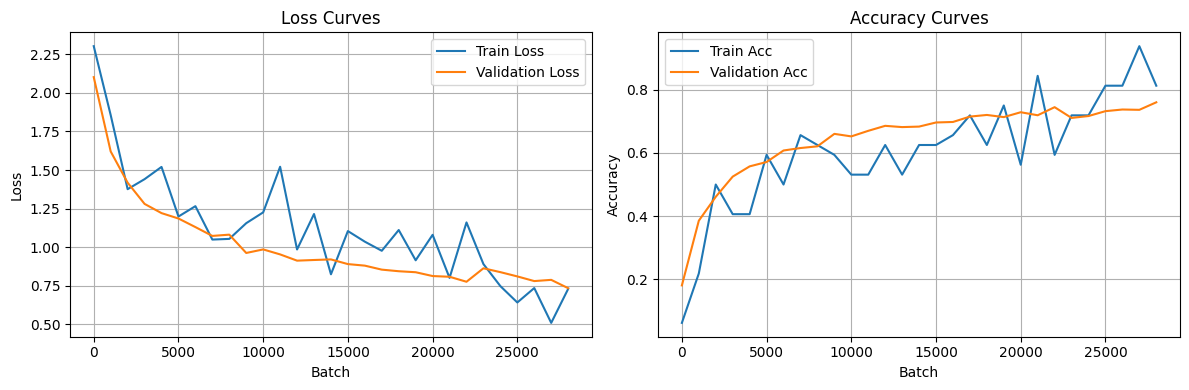

In [15]:
trainer.plot_curves()


In [16]:
!ls

02_cifar10_vgg_colab.ipynb    checkpoints   __pycache__  wangdao_train.py
02_cifar10_vgg.ipynb	      competitions  test.7z
07_cifar10_model_colab.ipynb  kaggle.json   train.7z


In [18]:
!ls ./competitions/cifar-10/test/1.png

./competitions/cifar-10/test/1.png


In [19]:
test_items = load_image_paths_and_labels(test_csv_file, test_folder)

In [20]:
test_df = pd.DataFrame(test_items, columns=["img_path", "label"])
test_df.head()

,img_path,label
0,competitions/cifar-10/test/1.png,cat
1,competitions/cifar-10/test/2.png,cat
2,competitions/cifar-10/test/3.png,cat
3,competitions/cifar-10/test/4.png,cat
4,competitions/cifar-10/test/5.png,cat


In [21]:
# 构建test_ds并推理，预测结果写入csv

# 假设Cifar10Dataset类、transforms_eval和idx_to_label已定义
test_ds = Cifar10Dataset("test", transforms_eval)
test_loader_final = torch.utils.data.DataLoader(test_ds, batch_size=128, shuffle=False)

all_preds = []
model.eval()
with torch.no_grad():
    for data in test_loader_final:
        images = data[0]
        images = images.to(device)
        outputs = model(images)
        _, predicted = outputs.max(1)
        all_preds.extend(predicted.cpu().numpy().tolist())

# 利用idx_to_label将id转换为类别名
all_labels = [Cifar10Dataset.idx_to_label[idx] for idx in all_preds]

import pandas as pd
# 生成带id的DataFrame
df = pd.DataFrame({
    "id": list(1, range(len(all_labels)) + 1),
    "label": all_labels
})
df.to_csv("cifar10_test_pred.csv", index=False)
